# Datset Loading and Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.neural_network import MLPClassifier

In [ ]:
df = pd.read_csv("KaggleV2-May-2016.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# EDA

In [ ]:
df.shape

(110527, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [ ]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Missing Values

In [ ]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


Target Distribution

Dataset is imbalanced.
Accuracy alone is misleading.

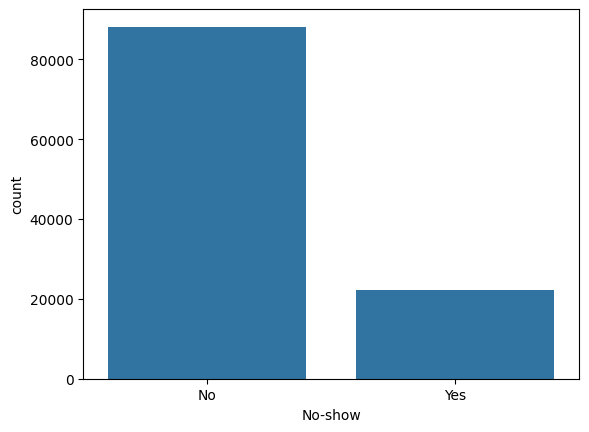

,proportion
No-show,
No,0.798067
Yes,0.201933


In [ ]:
sns.countplot(x='No-show', data=df)
plt.show()

df['No-show'].value_counts(normalize=True)

Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

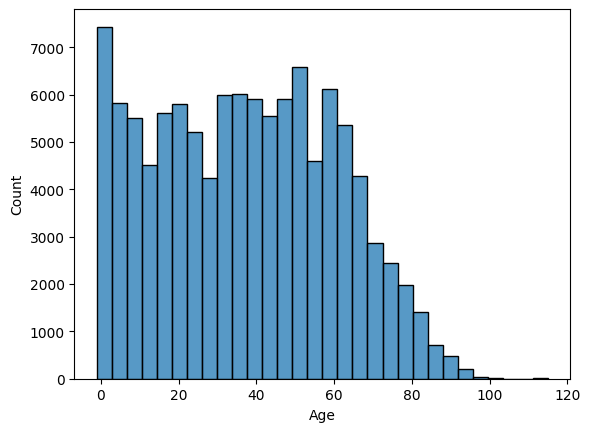

In [ ]:
sns.histplot(df['Age'], bins=30)

# Pre-processing and Feature Engineering

In [ ]:
# Remove invalid age
df = df[df['Age'] >= 0]

In [ ]:
# Dropping Irrelevant Columns
# IDs do not contribute to prediction and may cause data leakage.
df = df.drop(['PatientId', 'AppointmentID'], axis=1)

In [ ]:
# Encode Target (Convert Target to Binary)
# 1 = No-show
# 0 = Show
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

In [ ]:
# Convert Dates
# Lead time reflects scheduling delay and is strongly correlated with no-shows.
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [ ]:
# Waiting Days
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [ ]:
# Day of the week
df['appointment_day_of_week'] = df['AppointmentDay'].dt.dayofweek

In [ ]:
# Dropping original Date Column
df = df.drop(['ScheduledDay', 'AppointmentDay'], axis=1)

In [ ]:
# Encode Gender
df['Gender'] = df['Gender'].map({'M':1, 'F':0})

In [ ]:
df['Neighbourhood'].value_counts().head(10)

,count
Neighbourhood,
JARDIM CAMBURI,7717
MARIA ORTIZ,5805
RESISTÊNCIA,4431
JARDIM DA PENHA,3877
ITARARÉ,3514
CENTRO,3334
TABUAZEIRO,3132
SANTA MARTHA,3131
JESUS DE NAZARETH,2853


In [ ]:
df.groupby('Neighbourhood')['No-show'].agg(['mean','count']).sort_values('count', ascending=False)

,mean,count
Neighbourhood,,
JARDIM CAMBURI,0.189841,7717
MARIA ORTIZ,0.209991,5805
RESISTÊNCIA,0.204469,4431
JARDIM DA PENHA,0.162755,3877
ITARARÉ,0.262664,3514
...,...,...
ILHA DO BOI,0.085714,35
ILHA DO FRADE,0.200000,10
AEROPORTO,0.125000,8


Neighbourhood:

	•	Has small predictive power

	•	Adds 80 dimensions

	•	Increases overfitting risk

	•	Makes interpretation harder

In [ ]:
# Drop Neighbourhood
df = df.drop('Neighbourhood', axis=1)

In [ ]:
df['No-show'].value_counts()

,count
No-show,
0,88207
1,22319


In [ ]:
# Split Data
X = df.drop('No-show', axis=1)
y = df['No-show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Scale Numeric Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models


In [ ]:
# Model 1: Logistic Regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
# Model 2: Decision Tree
# Trees are scale-invariant because they split based on thresholds, not distances or gradients.
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [ ]:
# Model 3: MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)

In [ ]:
print("===== Logistic Regression =====")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\n")

print("===== Decision Tree =====")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_tree))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("\n")

print("===== Neural Network (MLP) =====")

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:", recall_score(y_test, y_pred_mlp))
print("F1 Score:", f1_score(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_mlp))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))
print("\n")

===== Logistic Regression =====
Accuracy: 0.6674658463765494
Precision: 0.3191329407342438
Recall: 0.5705645161290323
F1 Score: 0.4093210124548011
ROC-AUC: 0.6312747759196345
Confusion Matrix:
[[12208  5434]
 [ 1917  2547]]


===== Decision Tree =====
Accuracy: 0.7980638740613408
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5
Confusion Matrix:
[[17642     0]
 [ 4464     0]]


===== Neural Network (MLP) =====
Accuracy: 0.7966163032660816
Precision: 0.45209580838323354
Recall: 0.03382616487455197
F1 Score: 0.06294289287203002
ROC-AUC: 0.5117265956443954
Confusion Matrix:
[[17459   183]
 [ 4313   151]]




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump(mlp_model, f)

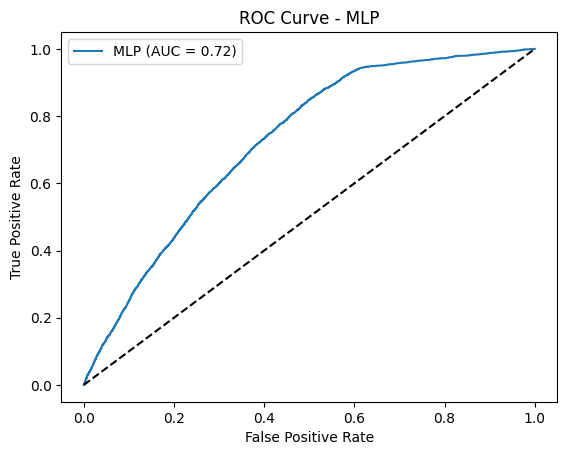

In [ ]:
y_probs_mlp = mlp_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs_mlp)

plt.plot(fpr, tpr, label="MLP (AUC = %.2f)" % roc_auc_score(y_test, y_probs_mlp))
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()
plt.show()